In [75]:
import numpy as np
import matplotlib.pyplot as plt

X = np.random.randint(0, 10, size=10)
X_sorted = X[np.argsort(X)]
Y = np.random.randint(0, 10, size=10)

Least Squares Slope: -0.0627306273062727
Least Squares Intercept: 4.413284132841327
Polynomial Fit Coefficients:  [ 0.04574175 -0.57901652  1.62080669  3.95631649]

Mean Squared Error for Each Method
Least Squares Method: 10.717343173431733
Cubic Polynomial Fit Method: 10.123292617920175

R-squared for Each Method
Least Squares Method: 0.00396438908627017
Cubic Polynomial Fit Method: 0.059173548520429886


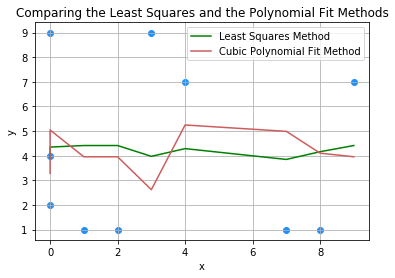

In [78]:
# Part A: Linear Least Squares vs Polynomial Fit
A = np.vstack([X, np.ones(len(X))]).T
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
Y_leastSquares = m * X + c

coefficients = np.polyfit(X, Y, 3)
polynomial = np.poly1d(coefficients)
Y_polyfit = polynomial(X)

# Printing information for each method
print(f"Least Squares Slope: {m}")
print(f"Least Squares Intercept: {c}")
print("Polynomial Fit Coefficients: ", coefficients)

# MSE for each method
mseLeastSquares = np.mean((Y - Y_leastSquares)**2)
msePolyfit = np.mean((Y - Y_polyfit)**2)

print("\nMean Squared Error for Each Method")
print(f"Least Squares Method: {mseLeastSquares}")
print(f"Cubic Polynomial Fit Method: {msePolyfit}")

# R-squared for each method
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res_ls = np.sum((Y - Y_leastSquares)**2)
r_squared_ls = 1 - (ss_res_ls / ss_total_ls)
ss_res_pf = np.sum((Y - Y_polyfit)**2)
r_squared_pf = 1 - (ss_res_pf / ss_total_pf)

print("\nR-squared for Each Method")
print(f"Least Squares Method: {r_squared_ls}")
print(f"Cubic Polynomial Fit Method: {r_squared_pf}")

# Plotting
plt.figure()
plt.scatter(X, Y, color='dodgerblue')
plt.plot(X_sorted, Y_leastSquares, color='green', label="Least Squares Method")
plt.plot(X_sorted, Y_polyfit, color='indianred', label="Cubic Polynomial Fit Method")
plt.title("Comparing the Least Squares and the Polynomial Fit Methods")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()

# Which method is the better fit?


Polynomial Fit of Degree 3
Coefficients:  [ 0.04574175 -0.57901652  1.62080669  3.95631649]
Mean Squared Error: 10.123292617920175
R-Squared: 0.059173548520429886



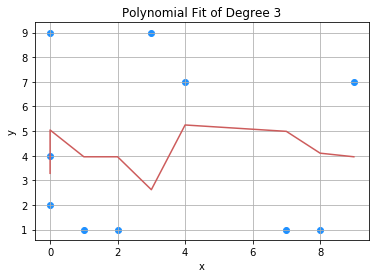

Polynomial Fit of Degree 4
Coefficients:  [ 0.06532326 -1.13738611  5.97779991 -9.04169157  4.96329359]
Mean Squared Error: 3.912292797479931
R-Squared: 0.6364040151040956



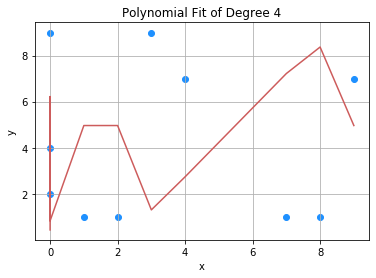

Polynomial Fit of Degree 5
Coefficients:  [-6.71701423e-03  2.11978784e-01 -2.22966485e+00  9.15100233e+00
 -1.20069375e+01  5.04685902e+00]
Mean Squared Error: 3.7212177737419907
R-Squared: 0.6541619169384767



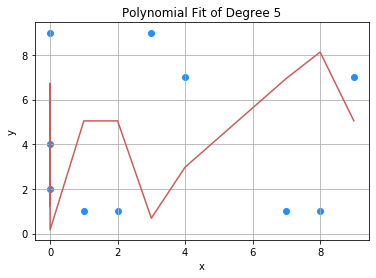

Polynomial Fit of Degree 6
Coefficients:  [-7.65276170e-05 -4.64900032e-03  1.91085791e-01 -2.13296254e+00
  8.95194852e+00 -1.18670053e+01  5.04535048e+00]
Mean Squared Error: 3.72106375484325
R-Squared: 0.6541762309625232



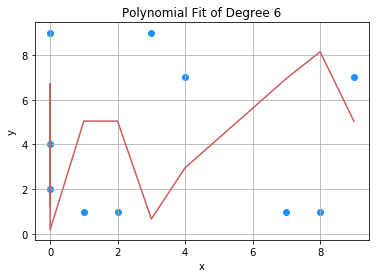

Polynomial Fit of Degree 7
Coefficients:  [ 6.81216931e-03 -2.13161376e-01  2.59649471e+00 -1.54103836e+01
  4.53506614e+01 -5.89478836e+01  2.26174603e+01  5.00000000e+00]
Mean Squared Error: 2.6
R-Squared: 0.758364312267658



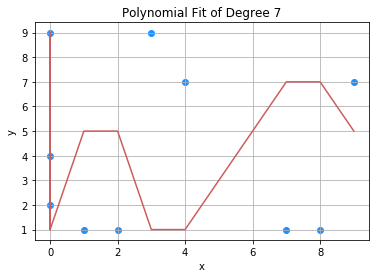

Polynomial Fit of Degree 8
Coefficients:  [ 5.52656175e-04 -1.19781407e-02  4.43764021e-02  7.70518705e-01
 -8.25403878e+00  3.00056100e+01 -4.24875721e+01  1.59325312e+01
  5.00000000e+00]
Mean Squared Error: 2.6
R-Squared: 0.758364312267658



/opt/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3326: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


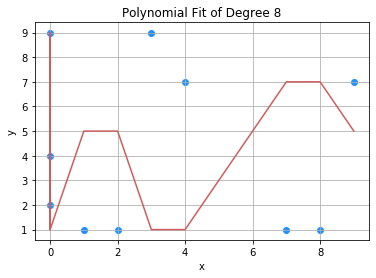

In [91]:
# Part B: Polynomial Fit with Increasing Degrees

# Cranking the polynomial up 1 degree at a time
for d in range(3, len(X) - 1):
    coefficients = np.polyfit(X, Y, d)
    polynomial = np.poly1d(coefficients)
    Y_polyfit = polynomial(X)
    
    # MSE and R-squared
    msePolyfit = np.mean((Y - Y_polyfit)**2)
    ss_total = np.sum((Y - np.mean(Y))**2)
    ss_res_pf = np.sum((Y - Y_polyfit)**2)
    r_squared_pf = 1 - (ss_res_pf / ss_total_pf)
    
    # Printing coefficients, MSE, and R-squared
    print(f"Polynomial Fit of Degree {d}")
    print("Coefficients: ", coefficients)
    print(f"Mean Squared Error: {msePolyfit}")
    print(f"R-Squared: {r_squared_pf}\n")
    
    # Plotting
    plt.figure()
    plt.scatter(X, Y, color='dodgerblue')
    plt.plot(X_sorted, Y_polyfit, color='indianred')
    plt.title(f"Polynomial Fit of Degree {d}")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid()
    plt.show()

Polynomial Fit of Degree 2
Coefficients:  [-0.00905106  0.01428687  4.35416836]
Mean Squared Error: 10.712874421625134
R-Squared: 0.004379700592459623



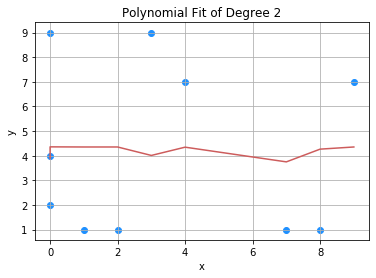

Polynomial Fit of Degree 1
Coefficients:  [-0.06273063  4.41328413]
Mean Squared Error: 10.717343173431736
R-Squared: 0.003964389086269837



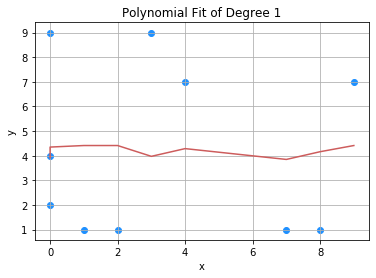

In [92]:
# Part B: Polynomial Fit with Decreasing Degrees

# Cranking the polynomial down 1 degree at a time
for d in range(2, 0, -1):
    coefficients = np.polyfit(X, Y, d)
    polynomial = np.poly1d(coefficients)
    Y_polyfit = polynomial(X)
    
    # MSE and R-squared
    msePolyfit = np.mean((Y - Y_polyfit)**2)
    ss_total = np.sum((Y - np.mean(Y))**2)
    ss_res_pf = np.sum((Y - Y_polyfit)**2)
    r_squared_pf = 1 - (ss_res_pf / ss_total_pf)
    
    # Printing coefficients, MSE, and R-squared
    print(f"Polynomial Fit of Degree {d}")
    print("Coefficients: ", coefficients)
    print(f"Mean Squared Error: {msePolyfit}")
    print(f"R-Squared: {r_squared_pf}\n")
    
    # Plotting
    plt.figure()
    plt.scatter(X, Y, color='dodgerblue')
    plt.plot(X_sorted, Y_polyfit, color='indianred')
    plt.title(f"Polynomial Fit of Degree {d}")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid()
    plt.show()

In [ ]:
# Part C: The Vandermonde